In [1]:
using DifferentialEquations, LinearAlgebra, Plots

In [2]:
#Basis state
r = [0;1]
g = [1;0]

#initial state of the system
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

n_atoms = 2

ψ_0 = [ψ_a,g,g]
ρ_0 = complex(reduce(kron,ψ_0) * reduce(kron,ψ_0)')

8×8 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im

In [3]:
struct parameters
    Ω1::Float64
    Ω2::Float64     
    γ_Decay::Float64     
    γ_dephase::Float64
    V1_nn::Float64 
    V2_nn::Float64     
 end

In [232]:
Δ1_0 = 3000
δ1 = -100
Δ2_0 = 3000
δ2 = -100

function linear_ramp(t,δ,Δ0)
    global Δ1_0 = Δ1_0
    global δ1 =  δ1
    global Δ2_0 = Δ2_0
    global δ2 =  δ2

    tf = -2*(Δ1_0+p.V1_nn)/δ1

    if t<tf
        return Δ0+δ*t
    else
        return Δ0+δ*(t-tf)
    end
end

function (p::parameters)(t)
    global Δ1_0 = Δ1_0
    global δ1 =  δ1
    global Δ2_0 = Δ2_0
    global δ2 =  δ2

    tf = -2*(Δ1_0+p.V1_nn)/δ1
    return (Δ1_0+δ1*t, Δ2_0+δ2*t, p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
    #return (linear_ramp(t,δ1,Δ1_0), linear_ramp(t,δ2,Δ2_0), p.Ω1, p.Ω2, p.γ_Decay, p.γ_dephase, p.V1_nn, p.V2_nn)
end

p = parameters(20,20,0.1,1,-2000,-1900)

parameters(20.0, 20.0, 0.1, 1.0, -2000.0, -1900.0)

In [233]:
p(22)

(800, 800, 20.0, 20.0, 0.1, 1.0, -2000.0, -1900.0)

In [234]:
nothing
function master_eqn(dρ,ρ,p,t)

    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    Π_g = [1 0; 0 0]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Δ1_t, Δ2_t, Ω1, Ω2, γ_Decay, γ_dephase, V1_nn, V2_nn = p(t)

    nn_sys = [kron(n,n,I), kron(I,n,n), kron(n,I,n)] 

    σminus_sys = [reduce(kron,[I,σ_minus,I]),reduce(kron,[I,I,σ_minus])]
    σplus_sys = [reduce(kron,[I,σ_plus,I]), reduce(kron,[I,I,σ_plus])]
    σz_sys = [reduce(kron,[I,σ_z,I]), reduce(kron,[I,I,σ_z])]
    n_sys = [reduce(kron,[I,n,I]), reduce(kron,[I,I,n])]
    σx_sys = [reduce(kron,[I,σ_x,I]), reduce(kron,[I,I,σ_x])]

    
    H = Ω1/2 .* σx_sys[1] + Ω2/2 .* σx_sys[2] + V1_nn .* nn_sys[1] + V2_nn.* nn_sys[2] +
        Δ1_t .* n_sys[1] + Δ2_t .*n_sys[2]
    l_decay = zeros(2^(n_atoms+1),2^(n_atoms+1))
    l_dephase = zeros(2^(n_atoms+1),2^(n_atoms+1))

    for i in 1:2
        l_decay += γ_Decay.*(σminus_sys[i] * ρ * σplus_sys[i] - 0.5.*((σplus_sys[i]*σminus_sys[i]*ρ)
                         + (ρ*σplus_sys[i]*σminus_sys[i])))
        l_dephase += γ_dephase.*(σz_sys[i]* ρ *σz_sys[i] - ρ)
    end

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
end

master_eqn (generic function with 1 method)

In [235]:
-2*(Δ1_0+p(0)[end-1])/δ1

20.0

In [236]:
-2*(Δ2_0+p(0)[end])/δ2

22.0

In [237]:
# Time span and solve the problem
tspan = (0.0,-2*(Δ1_0+p(0)[end-1])/δ1 - 2*(Δ2_0+p(0)[end])/δ2)
eqn = ODEProblem(master_eqn, ρ_0, tspan, p)
sol = solve(eqn, Rodas5(autodiff=false),saveat=0.01, progress=true)
#println(sol[end])

retcode: Success
Interpolation: 1st order linear
t: 4201-element Vector{Float64}:
  0.0
  0.01
  0.02
  0.03
  0.04
  0.05
  0.06
  0.07
  0.08
  0.09
  ⋮
 41.92
 41.93
 41.94
 41.95
 41.96
 41.97
 41.98
 41.99
 42.0
u: 4201-element Vector{Matrix{ComplexF64}}:
 [0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im]
 [0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.00036933448660704543 + 1.706099426675025e-17im -2.821645778229981e-6 + 7.133222201185271e-7im; 0.0 + 0.0im 0.0 + 0.0im … -2.8216457782371384e-6 - 7.133222201138357e-7im 2.3918931482973765e-8 - 4.921919867206206e-20im]
 [0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.00012596779722928047 - 5.70562437096692

In [238]:
tr(sol[end])

1.0000000000280498 + 1.8633539311338628e-8im

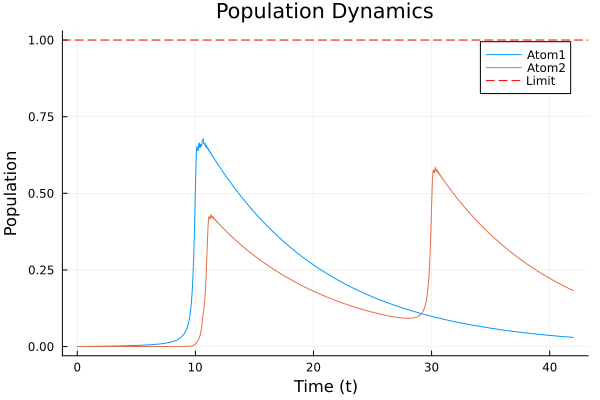

In [239]:
# Extracting populations from the solution
n = [0 0; 0 1]
I = [1 0; 0 1]

a = reduce(kron,[I,n,I])
rydberg1_populations = [tr(a*ρ) for ρ in sol.u]

b = reduce(kron,[I,I,n])
rydberg2_populations = [tr(b*ρ) for ρ in sol.u]

# Plotting the Rydberg state population over time
plot(sol.t, real(rydberg1_populations), label="Atom1", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")
plot!(sol.t, real(rydberg2_populations), label="Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics")
hline!([1],color=:red,linestyle=:dash,label="Limit")

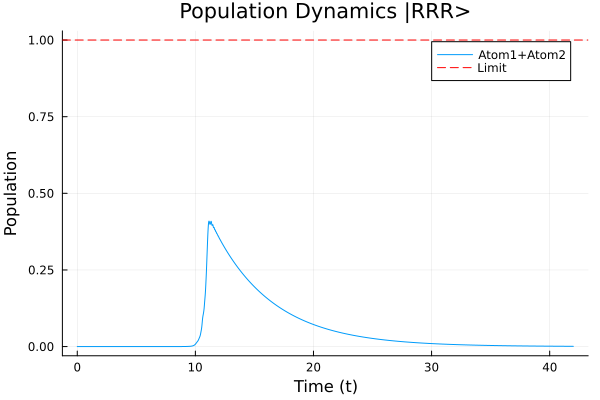

In [240]:
# Extracting populations from the solution
n = [0 0; 0 1]
I = [1 0; 0 1]

c = reduce(kron,[I,n,n])
rydberg12_populations = [tr(c*ρ) for ρ in sol.u]


# Plotting the Rydberg state population over time
plot(sol.t, real(rydberg12_populations), label="Atom1+Atom2", xlabel="Time (t)", ylabel="Population", title="Population Dynamics |RRR>")
hline!([1],color=:red,linestyle=:dash,label="Limit")

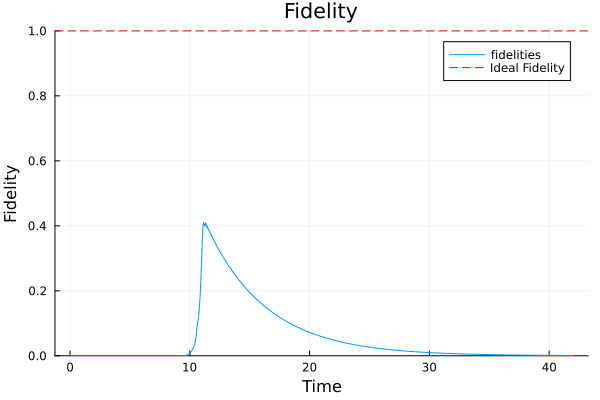

In [241]:
a = [r,r,r]
b = [g,g,g]
ψ_ideal = α*reduce(kron,a)+ β*reduce(kron,b)

fidelities = []
time = []
for (t,ρ) in zip(sol.t,sol.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

plot(time,real(fidelities),label="fidelities",xaxis="Time",yaxis="Fidelity",ylim=(0,1),title="Fidelity")
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

In [242]:
real(fidelities[end])

0.0009294974281711342

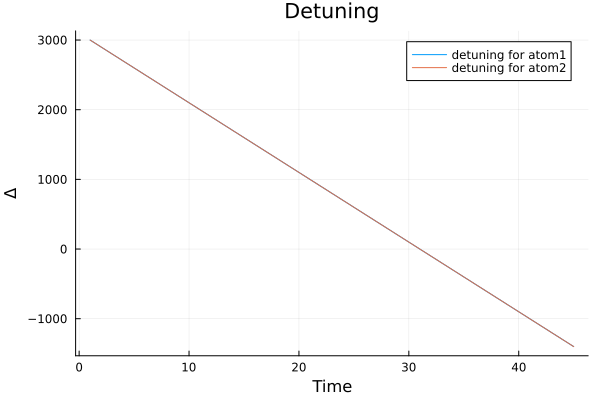

In [243]:
Δ1_T = []
Δ2_T = []
for t in range(0,-2*(Δ1_0+p(0)[end])/δ1 - 2*(Δ2_0+p(0)[end])/δ2)
    push!(Δ1_T,p(t)[1])
    push!(Δ2_T,p(t)[2])
end
plot(Δ1_T,label="detuning for atom1",xaxis="Time",yaxis="Δ",title="Detuning")
plot!(Δ2_T,label="detuning for atom2",xaxis="Time",yaxis="Δ",title="Detuning")

In [244]:
real(sol[end])

8×8 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0         0.0          0.0         0.0
 0.0  0.0  0.0  0.0  0.0         0.0          0.0         0.0
 0.0  0.0  0.0  0.0  0.0         0.0          0.0         0.0
 0.0  0.0  0.0  0.0  0.0         0.0          0.0         0.0
 0.0  0.0  0.0  0.0  0.788207    0.00505361   0.00237221  1.10799e-5
 0.0  0.0  0.0  0.0  0.00505361  0.181769     1.47256e-5  0.000354594
 0.0  0.0  0.0  0.0  0.00237221  1.47256e-5   0.0290946   9.0867e-5
 0.0  0.0  0.0  0.0  1.10799e-5  0.000354594  9.0867e-5   0.000929497